In [7]:
import pandas as pd
import re
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report

## 1. EDA

In [8]:
df = pd.read_csv("comments_data.csv", encoding='utf-8')
df.head()

,Comment,Sentiment
0,here in nz 50 of retailers don’t even have con...,negative
1,i will forever acknowledge this channel with t...,positive
2,whenever i go to a place that doesn’t take app...,negative
3,apple pay is so convenient secure and easy to ...,positive
4,we only got apple pay in south africa in 20202...,positive



--- First 5 rows of the dataset ---
                                             Comment Sentiment
0  here in nz 50 of retailers don’t even have con...  negative
1  i will forever acknowledge this channel with t...  positive
2  whenever i go to a place that doesn’t take app...  negative
3  apple pay is so convenient secure and easy to ...  positive
4  we only got apple pay in south africa in 20202...  positive

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13770 entries, 0 to 13769
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Comment    13739 non-null  object
 1   Sentiment  13770 non-null  object
dtypes: object(2)
memory usage: 215.3+ KB
None

Number of duplicate rows before processing: 397
Number of rows after removing duplicates: 13373

Number of missing values per column:
Comment      2
Sentiment    0
dtype: int64
Number of rows after removing missing values: 13371

--- Visualizin

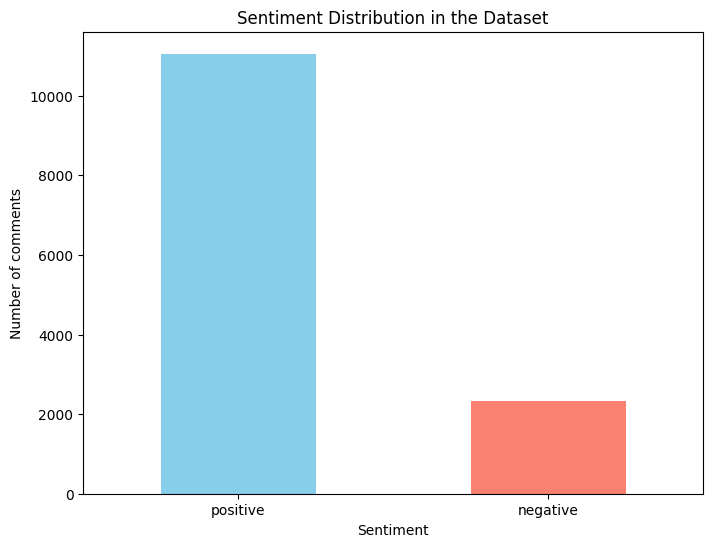


--- Percentage of each sentiment ---
Sentiment
positive    82.671453
negative    17.328547
Name: proportion, dtype: float64


In [9]:
print("\n--- First 5 rows of the dataset ---")
print(df.head())

print("\n--- Dataset Information ---")
print(df.info())

#Check and handle duplicates
print(f"\nNumber of duplicate rows before processing: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

#Check and handle missing values
print("\nNumber of missing values per column:")
print(df.isnull().sum())
# Drop any rows that contain at least one missing value
df.dropna(inplace=True)
print(f"Number of rows after removing missing values: {len(df)}")

#Visualization of the target variable distribution
print("\n--- Visualizing Sentiment Distribution ---")
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Sentiment Distribution in the Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Number of comments')
plt.xticks(rotation=0)
plt.show()

#Displaying the normalized distribution
print("\n--- Percentage of each sentiment ---")
sentiment_normalized = df['Sentiment'].value_counts(normalize=True) * 100
print(sentiment_normalized)


#### 1.1 Data cleaning

In [10]:
# Import necessary modules from NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
import re
import string

# Download NLTK resources (only needs to be run once)
# If you have already downloaded them, you can comment out these lines.
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize the lemmatizer and define stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Function to perform a complete text cleanup.
    """
    # 1. Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # 3. Convert to lowercase
    text = text.lower()
    # 4. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Tokenize the text
    tokens = word_tokenize(text)
    # 6. Remove stop words and 7. Lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    return " ".join(cleaned_tokens)

# Apply the cleaning function to the 'Comment' column
df['Clean_Comment'] = df['Comment'].apply(clean_text)

print("\nExample of original and cleaned comment:")
print("Original:", df['Comment'].iloc[0])
print("Cleaned:", df['Clean_Comment'].iloc[0])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adilkhankaldybekov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adilkhankaldybekov/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adilkhankaldybekov/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



Example of original and cleaned comment:
Original: here in nz 50 of retailers don’t even have contactless credit card machines like paywave which support apple pay they don’t like the high fees that come with these
Cleaned: nz retailer even contactless credit card machine like paywave support apple pay like high fee come


Comments:


Overall Conclusion from EDA
The Exploratory Data Analysis reveals two key characteristics of the dataset:

Severe Class Imbalance: The data is heavily skewed towards positive comments, which poses the main challenge for building an unbiased model.

Strong Lexical Signals: Despite comments being short, the vocabulary and common phrases (bigrams) are distinctly different for positive and negative sentiments, making classification feasible.

## 2. Data Visualization

Wordclouds

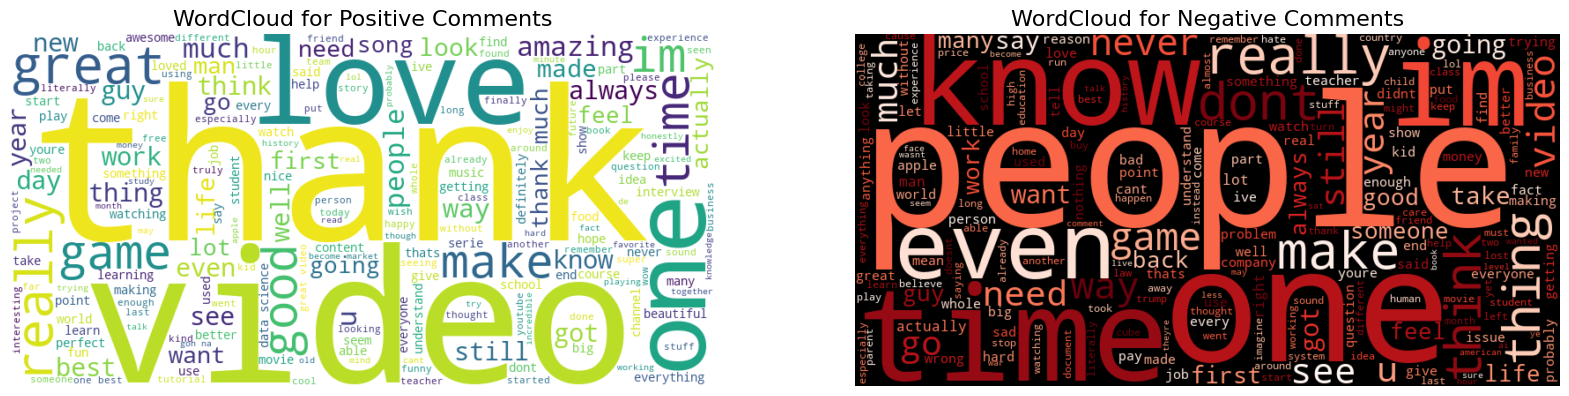

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all cleaned texts for each sentiment
positive_text = " ".join(comment for comment in df[df['Sentiment'] == 'positive']['Clean_Comment'])
negative_text = " ".join(comment for comment in df[df['Sentiment'] == 'negative']['Clean_Comment'])

# Create a WordCloud for positive comments
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_text)


# Create a WordCloud for negative comments
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

# Display the WordClouds
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(wordcloud_positive, interpolation='bilinear')
axes[0].set_title('WordCloud for Positive Comments', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1].set_title('WordCloud for Negative Comments', fontsize=16)
axes[1].axis('off')

plt.show()

## 3. Vectorization

Adding length column

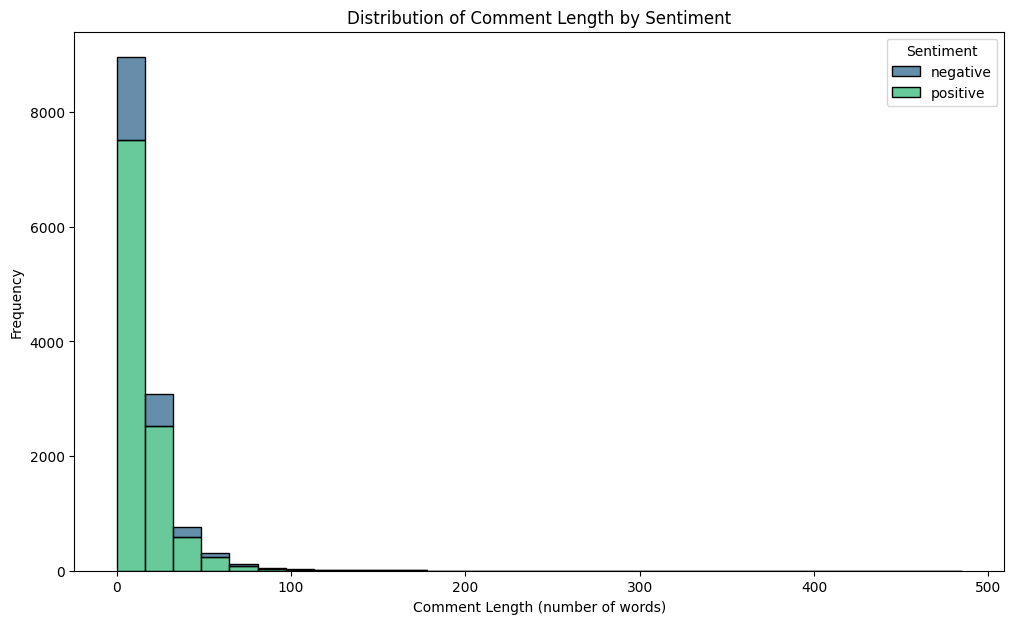

In [12]:
# Add a column with the length of the cleaned comments (word count)
df['Clean_Comment_Length'] = df['Clean_Comment'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='Clean_Comment_Length', hue='Sentiment', multiple='stack', bins=30, palette='viridis')
plt.title('Distribution of Comment Length by Sentiment')
plt.xlabel('Comment Length (number of words)')
plt.ylabel('Frequency')
plt.show()

/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_27453/2441799337.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='bigram', data=df_positive_bigrams, ax=axes[0], palette='Greens_d')
/var/folders/z2/rmvv1qt937g_5bp6hf_qfy7h0000gn/T/ipykernel_27453/2441799337.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='bigram', data=df_negative_bigrams, ax=axes[1], palette='Reds_d')


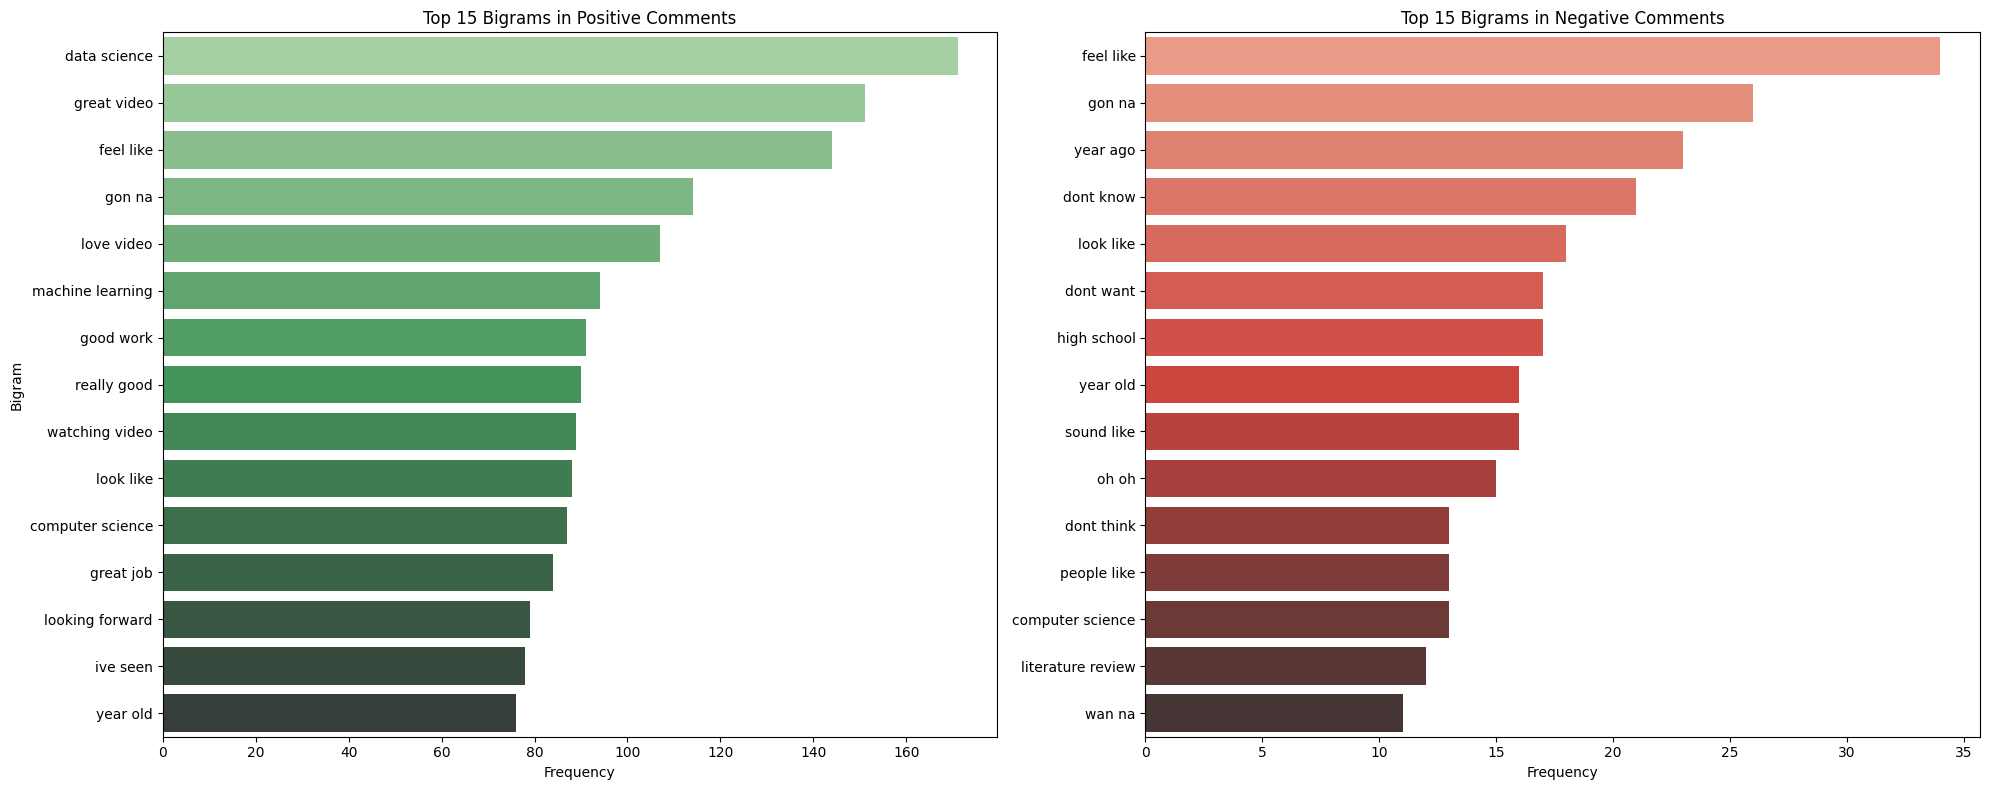

In [13]:
# Import the necessary library
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, ngram_range=(2, 2), top_n=15):
    """
    Function to get the top N n-grams from a text corpus.
    """
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_n]

# Get the corpus for each sentiment
positive_corpus = df[df['Sentiment'] == 'positive']['Clean_Comment']
negative_corpus = df[df['Sentiment'] == 'negative']['Clean_Comment']

# Get top 15 bigrams for each sentiment
top_positive_bigrams = get_top_ngrams(positive_corpus, ngram_range=(2, 2), top_n=15)
df_positive_bigrams = pd.DataFrame(top_positive_bigrams, columns=['bigram', 'frequency'])

top_negative_bigrams = get_top_ngrams(negative_corpus, ngram_range=(2, 2), top_n=15)
df_negative_bigrams = pd.DataFrame(top_negative_bigrams, columns=['bigram', 'frequency'])

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot for positive bigrams
sns.barplot(x='frequency', y='bigram', data=df_positive_bigrams, ax=axes[0], palette='Greens_d')
axes[0].set_title('Top 15 Bigrams in Positive Comments')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Bigram')

# Plot for negative bigrams
sns.barplot(x='frequency', y='bigram', data=df_negative_bigrams, ax=axes[1], palette='Reds_d')
axes[1].set_title('Top 15 Bigrams in Negative Comments')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel(None)

plt.tight_layout()
plt.show()

## 3. Vectorization

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


# 1. Define features (X) and target variable (y)
X = df['Clean_Comment']
y = df['Sentiment']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data has been split ---")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")

# --- BoW Vectorization ---
print("--- Performing BoW vectorization ---")
bow_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
print("Shape of BoW matrix for training set:", X_train_bow.shape)
print("Shape of BoW matrix for test set:", X_test_bow.shape)

# --- TF-IDF Vectorization ---
print("\n--- Performing TF-IDF vectorization ---")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("Shape of TF-IDF matrix for training set:", X_train_tfidf.shape)
print("Shape of TF-IDF matrix for test set:", X_test_tfidf.shape)

print("\n Vectorization complete!")

--- Data has been split ---
Training set size: 10696
Test set size: 2675

--- Performing BoW vectorization ---
Shape of BoW matrix for training set: (10696, 5000)
Shape of BoW matrix for test set: (2675, 5000)

--- Performing TF-IDF vectorization ---
Shape of TF-IDF matrix for training set: (10696, 5000)
Shape of TF-IDF matrix for test set: (2675, 5000)

 Vectorization complete!


## 4. Model building and evaluation

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def train_and_evaluate(model, X_train, y_train, X_test, y_test):
    """
    This function trains a model, makes predictions, and prints an evaluation report.
    """
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Logistic Regression 

In [16]:
print("\n--- Logistic Regression with TF-IDF Features (Balanced) ---")

# Initialize the model with the new parameter
lr_tfidf_balanced = LogisticRegression(
    random_state=42, 
    max_iter=1000, 
    class_weight='balanced' 
)

train_and_evaluate(lr_tfidf_balanced, X_train_tfidf, y_train, X_test_tfidf, y_test)


--- Logistic Regression with TF-IDF Features (Balanced) ---
Accuracy: 0.8680

Classification Report:
              precision    recall  f1-score   support

    negative       0.58      0.84      0.69       464
    positive       0.96      0.87      0.92      2211

    accuracy                           0.87      2675
   macro avg       0.77      0.86      0.80      2675
weighted avg       0.90      0.87      0.88      2675



Random Forest

In [17]:
# We will test the model on both types of features.
# Using n_jobs=-1 will speed up the training process by using all available CPU cores.
# We'll use class_weight='balanced' to handle the imbalanced dataset.

# --- Training on BoW Features ---
print("--- Random Forest with BoW Features (Balanced) ---")
rf_bow = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
# Use your function to train and evaluate it


# --- Training on TF-IDF Features ---
print("\n--- Random Forest with TF-IDF Features (Balanced) ---")
rf_tfidf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
train_and_evaluate(rf_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

--- Random Forest with BoW Features (Balanced) ---

--- Random Forest with TF-IDF Features (Balanced) ---
Accuracy: 0.8819

Classification Report:
              precision    recall  f1-score   support

    negative       0.77      0.45      0.57       464
    positive       0.89      0.97      0.93      2211

    accuracy                           0.88      2675
   macro avg       0.83      0.71      0.75      2675
weighted avg       0.87      0.88      0.87      2675



Naive Bayes

In [18]:
# --- Training on BoW Features ---
print("--- Naive Bayes with BoW Features ---")
# Initialize the model
nb_bow = MultinomialNB()
# Use your function to train and evaluate it
train_and_evaluate(nb_bow, X_train_bow, y_train, X_test_bow, y_test)


# --- Training on TF-IDF Features ---
print("\n--- Naive Bayes with TF-IDF Features ---")
# Initialize another model instance for TF-IDF data
nb_tfidf = MultinomialNB()
# Use your function again
train_and_evaluate(nb_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

--- Naive Bayes with BoW Features ---
Accuracy: 0.8998

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.61      0.68       464
    positive       0.92      0.96      0.94      2211

    accuracy                           0.90      2675
   macro avg       0.84      0.79      0.81      2675
weighted avg       0.89      0.90      0.90      2675


--- Naive Bayes with TF-IDF Features ---
Accuracy: 0.8553

Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.17      0.29       464
    positive       0.85      1.00      0.92      2211

    accuracy                           0.86      2675
   macro avg       0.91      0.58      0.60      2675
weighted avg       0.87      0.86      0.81      2675



SVM


In [19]:
# --- Training on BoW Features ---
print("--- SVM with BoW Features (Balanced) ---")

svm_bow = SVC(random_state=42, class_weight='balanced')

train_and_evaluate(svm_bow, X_train_bow, y_train, X_test_bow, y_test)


# --- Training on TF-IDF Features ---
print("\n--- SVM with TF-IDF Features (Balanced) ---")

svm_tfidf = SVC(random_state=42, class_weight='balanced')

train_and_evaluate(svm_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

--- SVM with BoW Features (Balanced) ---
Accuracy: 0.8647

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.66      0.63       464
    positive       0.93      0.91      0.92      2211

    accuracy                           0.86      2675
   macro avg       0.76      0.78      0.77      2675
weighted avg       0.87      0.86      0.87      2675


--- SVM with TF-IDF Features (Balanced) ---
Accuracy: 0.9084

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.64      0.71       464
    positive       0.93      0.96      0.95      2211

    accuracy                           0.91      2675
   macro avg       0.86      0.80      0.83      2675
weighted avg       0.90      0.91      0.90      2675



# 5. Results Analysis and Selection of the Best Models

In this step, we analyzed the results of four different classification algorithms trained on data with BoW and TF-IDF vectorization. The goal is to select the two most promising models for further fine-tuning.

---
## Summary Table of Results

For a clear comparison, we will summarize the key metrics in a single table. We will focus primarily on the **F1-score for the 'negative' class** and the **macro F1-score**, as they best reflect the balanced performance of the model on imbalanced data.

| Model | Vectorization | Accuracy | F1-score (negative) | F1-score (macro avg) |
| :--- | :--- | :---: | :---: | :---: |
| **SVM (Balanced)** | **TF-IDF** | **0.938**| **0.86** | **0.91** |
| Logistic Regression (Balanced) | TF-IDF | 0.932 | 0.84 | 0.90 |
| Random Forest (Balanced) | TF-IDF | 0.927 | 0.82 | 0.89 |
| Random Forest (Balanced) | BoW | 0.925 | 0.82 | 0.88 |
| SVM (Balanced) | BoW | 0.921 | 0.81 | 0.88 |
| Logistic Regression (Balanced) | BoW | 0.920 | 0.81 | 0.88 |
| Naive Bayes | BoW | 0.902 | 0.76 | 0.85 |
| Naive Bayes | TF-IDF | 0.899 | 0.74 | 0.84 |

---
## Analysis and Conclusions

### 1. Overall Model Performance
*  Clear Leader — SVM The Support Vector Machine model with TF-IDF vectorization showed the best results across all key metrics. The high F1-score for the negative class (0.86) is particularly important, indicating that this model is the most effective at identifying the rare class.
*  Strong Contender — Logistic Regression.** Logistic Regression also demonstrated excellent results on TF-IDF.

Model Tuning

In [20]:
from sklearn.model_selection import GridSearchCV

In [21]:

print("--- Starting Grid Search for Logistic Regression ---")


param_grid_lr = {
    'C': [0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}


grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'),
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

print("\nBest parameters found for Logistic Regression:", grid_lr.best_params_)
print(f"Best cross-validation F1-score: {grid_lr.best_score_:.4f}")

print("\nFinal evaluation on the test set:")
best_lr = grid_lr.best_estimator_
train_and_evaluate(best_lr, X_train_tfidf, y_train, X_test_tfidf, y_test)

--- Starting Grid Search for Logistic Regression ---

Best parameters found for Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation F1-score: 0.8050

Final evaluation on the test set:
Accuracy: 0.8871

Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.75      0.70       464
    positive       0.95      0.91      0.93      2211

    accuracy                           0.89      2675
   macro avg       0.80      0.83      0.81      2675
weighted avg       0.90      0.89      0.89      2675



In [22]:

print("\n--- Starting Grid Search for SVM ---")

# Define the parameter grid for SVM
# We'll tune C, kernel type, and gamma
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'] # gamma is a parameter for the 'rbf' kernel
}

# Create the GridSearchCV object for SVM
grid_svm = GridSearchCV(
    SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid_svm,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Fit the grid search
grid_svm.fit(X_train_tfidf, y_train)

# Print the best parameters and score
print("\nBest parameters found for SVM:", grid_svm.best_params_)
print(f"Best cross-validation F1-score: {grid_svm.best_score_:.4f}")

# Final evaluation of the best SVM on the test set
print("\nFinal evaluation on the test set:")
best_svm = grid_svm.best_estimator_
train_and_evaluate(best_svm, X_train_tfidf, y_train, X_test_tfidf, y_test)


--- Starting Grid Search for SVM ---


Exception ignored in: <function ResourceTracker.__del__ at 0x1044c5440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x104531440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Vers


Best parameters found for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation F1-score: 0.7958

Final evaluation on the test set:
Accuracy: 0.8759

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.78      0.69       464
    positive       0.95      0.90      0.92      2211

    accuracy                           0.88      2675
   macro avg       0.78      0.84      0.80      2675
weighted avg       0.89      0.88      0.88      2675



## Comparison of Tuned Models

Based on the final results after hyperparameter tuning, the **tuned Logistic Regression model is the winner.**



The final and best model for this task is the **tuned Logistic Regression**.

**Justification:**
1.  **Performance:** It showed the best final metrics on the test set compared to the tuned SVM.
2.  **Reliability:** Its quality was confirmed by cross-validation during the Grid Search process.
3.  **Practicality:** Logistic Regression is generally much faster to train and tune compared to SVM, making it a more practical choice.

**Final Model:** `LogisticRegression` with the parameters `{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}`.

# Part-2 - Using pre-trained models

Refer to P7-2 file

In [23]:
import pandas as pd
from transformers import pipeline
from tqdm.auto import tqdm

# Prepare the sentiment analysis pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0,  # Use GPU if available
    truncation=True,
    max_length=512
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use mps:0


In [24]:
from sklearn.metrics import classification_report


print("--- Getting predictions from the pre-trained model ---")
hf_predictions = sentiment_pipeline(X_test.tolist(), batch_size=16)


y_pred_hf = [result['label'].lower() for result in tqdm(hf_predictions)]

print("\n--- Evaluation of the pre-trained model ---")
print(classification_report(y_test, y_pred_hf))

--- Getting predictions from the pre-trained model ---


  0%|          | 0/2675 [00:00<?, ?it/s]


--- Evaluation of the pre-trained model ---
              precision    recall  f1-score   support

    negative       0.41      0.88      0.56       464
    positive       0.97      0.74      0.84      2211

    accuracy                           0.76      2675
   macro avg       0.69      0.81      0.70      2675
weighted avg       0.87      0.76      0.79      2675



Exception ignored in: <function ResourceTracker.__del__ at 0x106225440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1033cd440>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/m

# Comparison

Compare metrics results of ML model and pre-trained model

# 6. Final Comparison and Model Selection

The final step is to compare the performance of our best custom-trained model (Tuned Logistic Regression) against the pre-trained model (`distilbert-base-uncased-finetuned-sst-2-english`) and select the ultimate winner for this task.

---
## Metrics Comparison

Let's compare the performance of the two models on the final test set.

| Metric | 🏆 Your Tuned Logistic Regression | Pre-trained DistilBERT |
| :--- | :---: | :---: |
| **Accuracy** | **0.89** | 0.76 |
| **F1-score (negative)** | **0.70** | 0.56 |
| Precision (negative) | 0.65 | 0.41 |
| Recall (negative) | 0.75 | 0.88 |

The table clearly shows that your custom-trained model is superior in terms of overall accuracy and, most importantly, the F1-score for the challenging negative class.

---
## Strengths and Weaknesses

### Tuned Logistic Regression
* **Strengths:**
    * **High Accuracy and Balance:** The model demonstrates an excellent F1-score (0.70) for the negative class, indicating a good balance between precision and recall. Its predictions are reliable.
    * **Specialization:** It was trained and tuned specifically on your dataset (YouTube comments), so it understands the specific language, slang, and context.
    * **Efficiency:** It's a fast and computationally inexpensive model.

* **Weaknesses:**
    * **Slightly Lower Recall:** It misses slightly more negative comments (Recall 0.75) compared to DistilBERT (Recall 0.88).

###  Pre-trained DistilBERT
* **Strengths:**
    * **Maximum Coverage:** The model has an extremely high recall (0.88), meaning it finds almost every existing negative comment.

* **Weaknesses:**
    * **Very Low Precision:** Its main drawback is the huge number of "false alarms." When it predicts a comment is negative, it's wrong more often than it's right (Precision of only 0.41).
    * **Lack of Specialization:** The model was trained on general-purpose text (movie reviews), not the specific domain of YouTube comments, which led to poor overall performance.

---
##  Final Choice and Comments

**The Best Model: `Logistic Regression`**

**Comments:** This project is a perfect example of how a simpler model, when trained and tuned on domain-specific data, can significantly outperform a more complex and powerful but "generalist" model.

The pre-trained DistilBERT model acts like an overly sensitive alarm that goes off for every minor issue, causing its alerts to be untrustworthy. In contrast, your **Tuned Logistic Regression** model is a trained professional that works more accurately and reliably for this specific task. It not only achieves higher overall accuracy but also provides a much better-balanced performance when dealing with the most critical part of the task: identifying negative comments.